# BrainScanAI — Notebook 1 : exploration, features et clustering

**Contexte.** CurelyticsIA veut savoir s'il est possible d'automatiser la détection de tumeurs cérébrales sur IRM. Sur 1 500 images, seules 100 ont été annotées par des radiologues (normal / cancer) ; le reste n'a aucune étiquette.

**Objectif de ce notebook :**
1. Explorer le jeu de données
2. Préparer les images et extraire des features avec un modèle pré-entraîné
3. Réduire la dimension, appliquer un clustering et produire des labels « faibles »

---

## Étape 1 — Exploration du jeu de données

Avant tout traitement, on vérifie ce qu'on a réellement entre les mains : nombre d'images, dimensions, canaux de couleur, qualité des fichiers. Chaque anomalie repérée ici peut fausser les étapes suivantes.

### 1.1 Imports et chemin des données

Tout le chemin vers les données tient dans une seule variable `DATA_DIR` : c'est la seule ligne à modifier si on exécute le notebook ailleurs (sur Colab par exemple).

In [1]:
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# Dossier du dataset (à adapter si on travaille sur Colab)
DATA_DIR = Path("../mri_dataset_brain_cancer_oc")

### 1.2 Inventaire des images

On parcourt tous les fichiers `.jpg` et on range leurs informations dans un DataFrame. Le sous-ensemble (`avec_labels` / `sans_label`) et le label (`cancer` / `normal`) se déduisent directement de l'arborescence des dossiers.

In [2]:
rows = []
for path in sorted(DATA_DIR.rglob("*.jpg")):
    rel = path.relative_to(DATA_DIR)
    subset = rel.parts[0]                                      # "avec_labels" ou "sans_label"
    label = rel.parts[1] if subset == "avec_labels" else None  # "cancer" / "normal", ou rien
    rows.append({"path": path, "subset": subset, "label": label})

df = pd.DataFrame(rows)

# Colonne pratique pour les graphiques : cancer / normal / sans_label
df["groupe"] = df["label"].fillna("sans_label")

print(f"{len(df)} images au total")
df["groupe"].value_counts()

1506 images au total


groupe
sans_label    1406
cancer          50
normal          50
Name: count, dtype: int64

### 1.3 Propriétés techniques des images

Pour chaque image, on lit ses dimensions, son mode couleur (`L` = niveaux de gris, `RGB` = couleur) et le poids du fichier. La doc annonce des images 512×512 : on vérifie que c'est bien le cas partout.

In [3]:
def image_info(path):
    """Ouvre l'image et renvoie ses caractéristiques techniques."""
    with Image.open(path) as img:
        return {"width": img.width, "height": img.height, "mode": img.mode, "format": img.format}

infos = pd.DataFrame([image_info(p) for p in df["path"]])
df = pd.concat([df, infos], axis=1)
df["file_kb"] = df["path"].apply(lambda p: p.stat().st_size / 1024)

# Combinaisons dimensions / mode couleur / format rencontrées
df.groupby(["width", "height", "mode", "format"]).size().rename("nb_images")

width  height  mode  format
512    512     RGB   JPEG      1506
Name: nb_images, dtype: int64

In [4]:
# Distribution du poids des fichiers (en Ko) par groupe
df.groupby("groupe")["file_kb"].describe().round(1)

,count,mean,std,min,25%,50%,75%,max
groupe,,,,,,,,
cancer,50.0,22.5,4.0,15.8,19.3,23.0,25.2,31.8
normal,50.0,29.1,11.4,17.4,23.0,25.3,29.4,64.3
sans_label,1406.0,24.1,5.8,13.1,20.6,23.2,26.6,73.7


### 1.4 Vraies couleurs ou niveaux de gris déguisés ?

Une IRM est par nature en niveaux de gris. Si les images sont stockées en RGB, les trois canaux devraient être (presque) identiques. On mesure pour chaque image l'écart maximal entre canaux : 0 = gris parfait. La compression JPEG peut créer de petits écarts, d'où un seuil de tolérance.

C'est important pour l'étape 2 : ResNet attend 3 canaux en entrée. Si les images sont grises, on dupliquera le canal gris.

In [5]:
def channel_diff(path):
    """Écart maximal entre les canaux R, G et B de l'image (0 = image grise)."""
    arr = np.asarray(Image.open(path).convert("RGB"), dtype=np.int16)
    return max(
        np.abs(arr[..., 0] - arr[..., 1]).max(),
        np.abs(arr[..., 1] - arr[..., 2]).max(),
    )

df["channel_diff"] = df["path"].apply(channel_diff)

TOLERANCE = 10  # écart toléré, lié à la compression JPEG
df["is_gray"] = df["channel_diff"] <= TOLERANCE

print(df["channel_diff"].describe().round(1))
df.groupby("groupe")["is_gray"].mean().rename("part_images_grises")

count    1506.0
mean        0.2
std         3.2
min         0.0
25%         0.0
50%         0.0
75%         0.0
max        81.0
Name: channel_diff, dtype: float64


groupe
cancer        1.00000
normal        1.00000
sans_label    0.99431
Name: part_images_grises, dtype: float64

### 1.5 Visualisation d'exemples

On affiche quelques images tirées au hasard dans chaque groupe. C'est l'étape la plus simple et souvent la plus instructive : cadrage, contraste, orientation, présence visible de la tumeur.

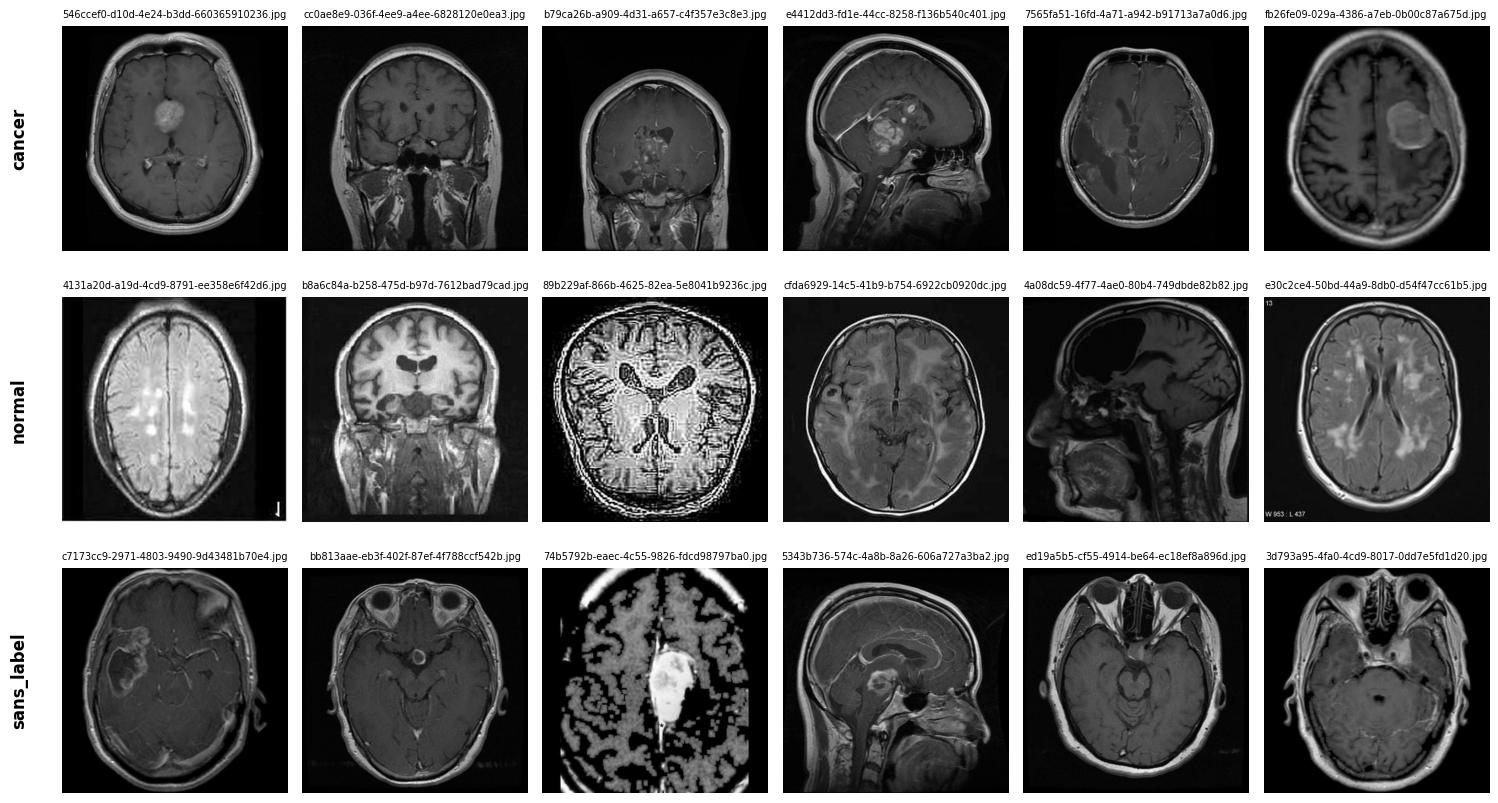

In [6]:
N_PER_ROW = 6
groupes = ["cancer", "normal", "sans_label"]

fig, axes = plt.subplots(len(groupes), N_PER_ROW, figsize=(2.5 * N_PER_ROW, 2.8 * len(groupes)))
for row, groupe in enumerate(groupes):
    # Tirage aléatoire reproductible (random_state fixé)
    sample = df[df["groupe"] == groupe].sample(N_PER_ROW, random_state=42)
    for col, path in enumerate(sample["path"]):
        ax = axes[row, col]
        ax.imshow(Image.open(path), cmap="gray")
        ax.set_title(path.name, fontsize=7)
        ax.axis("off")
    axes[row, 0].text(-0.15, 0.5, groupe, transform=axes[row, 0].transAxes,
                      rotation=90, va="center", ha="right", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

### 1.6 Qualité : fichiers corrompus et doublons

Deux vérifications :
- **Fichiers corrompus** : `Image.verify()` contrôle l'intégrité de chaque fichier.
- **Doublons exacts** : on calcule une empreinte MD5 du contenu de chaque fichier. Deux fichiers avec la même empreinte sont strictement identiques. Cela pourrait expliquer les 1 406 images sans label, alors que la doc en annonce 1 400.

Point d'attention : un doublon **entre** `avec_labels` et `sans_label` serait une fuite de données, puisque la même image se retrouverait à la fois dans le jeu fort et dans le jeu faible.

In [7]:
def is_valid(path):
    """True si le fichier image est lisible et non corrompu."""
    try:
        with Image.open(path) as img:
            img.verify()
        return True
    except Exception:
        return False

df["is_valid"] = df["path"].apply(is_valid)
print(f"Fichiers corrompus : {(~df['is_valid']).sum()}")

# Empreinte MD5 du contenu de chaque fichier
df["md5"] = df["path"].apply(lambda p: hashlib.md5(p.read_bytes()).hexdigest())
dups = df[df.duplicated("md5", keep=False)].sort_values("md5")

print(f"Images impliquées dans un doublon : {len(dups)}")
print(f"Groupes de doublons : {dups['md5'].nunique()}")

# Doublons qui traversent plusieurs groupes (risque de fuite de données)
cross = dups.groupby("md5")["groupe"].nunique()
print(f"Groupes de doublons à cheval sur plusieurs groupes : {(cross > 1).sum()}")

dups[["md5", "groupe", "path"]].assign(path=dups["path"].apply(lambda p: p.name))

Fichiers corrompus : 0
Images impliquées dans un doublon : 186
Groupes de doublons : 90
Groupes de doublons à cheval sur plusieurs groupes : 31


,md5,groupe,path
651,038bd3a36c6463f3a9f18ac031ea1c4d,sans_label,63f74ae7-15f3-40e6-90f8-850dd20dbb70.jpg
988,038bd3a36c6463f3a9f18ac031ea1c4d,sans_label,a74cd797-2401-44e9-b29b-e3e125c8e148.jpg
1086,0652cb55477c4edeea5c5dfd53944e3b,sans_label,b65c7ebe-aac9-414e-a9d3-b8205d5d5a23.jpg
97,0652cb55477c4edeea5c5dfd53944e3b,normal,defdbef3-bea2-4f32-9d9a-62af1102ebfd.jpg
369,0816537db58c1d8092808f2c6f75e96c,sans_label,2f0c7977-339e-4e46-b412-c8fd1a8d05b0.jpg
...,...,...,...
51,fa2f6066ee4f4e22f35c46c4ddf8584b,normal,09316c60-86c8-4f24-934e-8d433b8b9d72.jpg
187,fdc753e2225fcf328308438eb4f37058,sans_label,0e6c3f73-189a-420c-b17e-17dd19ac7736.jpg
579,fdc753e2225fcf328308438eb4f37058,sans_label,592e9fb8-cf27-4acf-ab1f-7644e76ff88e.jpg
1074,fe822536fc06483aeea76f22e3709f50,sans_label,b3d19755-4df5-4a8a-9206-92f244ea82bc.jpg


### 1.7 Traitement des doublons

Les 1 506 fichiers ne correspondent qu'à environ 1 410 images réellement différentes. On distingue trois cas, qui n'ont pas la même gravité :

| Cas | Conséquence si on ne fait rien |
| --- | --- |
| Plusieurs copies d'une même image dans `sans_label` | Certaines images pèsent 2 ou 3 fois plus que les autres dans le clustering et dans l'entraînement : un biais léger. |
| Deux copies d'une même image dans `normal` | On croit avoir 50 images normales alors qu'on n'en a que 49. |
| **Une image labellisée dont une copie se trouve dans `sans_label`** | **Fuite de données.** La copie recevrait un label faible et servirait à l'entraînement, alors que l'original peut finir dans le jeu de test fort. Le modèle serait évalué sur des images qu'il a déjà vues, et les scores du semi-supervisé seraient artificiellement gonflés. |

**Règle appliquée :** on ne garde qu'**une seule copie** de chaque image (identifiée par son empreinte MD5). Quand une image existe à la fois avec et sans label, c'est la **version labellisée qui est conservée** : l'étiquette d'un radiologue vaut plus qu'une étiquette faible, et on retire ainsi toute trace des images labellisées dans `sans_label`.

Les fichiers d'origine ne sont pas modifiés : on travaille sur un DataFrame nettoyé, `df_clean`, qui servira de référence pour toute la suite du projet.

In [8]:
# Priorité : une copie labellisée (0) passe avant une copie sans label (1)
priority = {"cancer": 0, "normal": 0, "sans_label": 1}

df_clean = (
    df.assign(prio=df["groupe"].map(priority))
      .sort_values(["prio", "path"])            # les copies labellisées passent en premier
      .drop_duplicates("md5", keep="first")     # on garde la première copie de chaque image
      .drop(columns="prio")
      .sort_index()
      .reset_index(drop=True)
)

# Vérification : plus aucune empreinte partagée entre images labellisées et non labellisées
md5_labels = set(df_clean.loc[df_clean["subset"] == "avec_labels", "md5"])
md5_sans_label = set(df_clean.loc[df_clean["subset"] == "sans_label", "md5"])
assert md5_labels.isdisjoint(md5_sans_label), "Fuite : une image labellisée est encore dans sans_label"

pd.DataFrame({
    "avant": df["groupe"].value_counts(),
    "après": df_clean["groupe"].value_counts(),
}).assign(retirées=lambda t: t["avant"] - t["après"])

,avant,après,retirées
groupe,,,
sans_label,1406,1311,95
cancer,50,50,0
normal,50,49,1


On sauvegarde l'inventaire nettoyé en CSV. Les chemins y sont stockés **relativement à `DATA_DIR`**, pour que le fichier reste utilisable si le dataset est placé ailleurs (sur Colab par exemple).

In [9]:
OUTPUT_DIR = Path("../outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

inventaire = df_clean[["path", "subset", "label", "groupe", "md5"]].copy()
inventaire["path"] = inventaire["path"].apply(lambda p: p.relative_to(DATA_DIR).as_posix())
inventaire.to_csv(OUTPUT_DIR / "inventaire_images.csv", index=False)

print(f"{len(inventaire)} images sauvegardées dans {OUTPUT_DIR / 'inventaire_images.csv'}")

1410 images sauvegardées dans ../outputs/inventaire_images.csv


### 1.8 Intensité des images

On calcule la luminosité moyenne de chaque image (moyenne des pixels en niveaux de gris, entre 0 et 255) et on compare les groupes, sur le jeu dédoublonné. Un écart marqué entre `cancer` et `normal` serait un signal à surveiller : le modèle pourrait apprendre à reconnaître la luminosité plutôt que la tumeur.

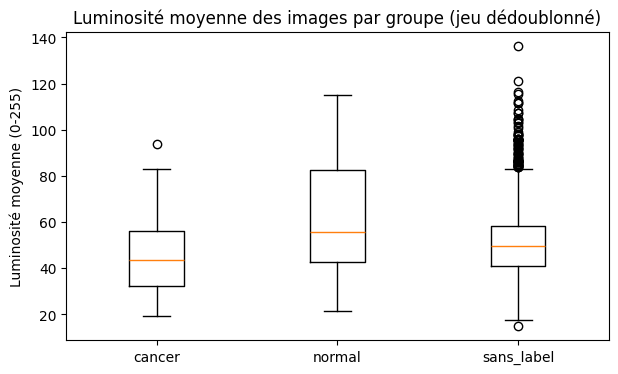

,count,mean,std,min,25%,50%,75%,max
groupe,,,,,,,,
cancer,50.0,46.0,15.5,19.5,32.5,43.6,56.2,94.0
normal,49.0,62.0,23.8,21.5,42.7,55.6,82.4,115.2
sans_label,1311.0,51.6,16.6,14.9,41.2,49.9,58.1,136.2


In [10]:
df_clean["mean_intensity"] = df_clean["path"].apply(lambda p: np.asarray(Image.open(p).convert("L")).mean())

fig, ax = plt.subplots(figsize=(7, 4))
data = [df_clean.loc[df_clean["groupe"] == g, "mean_intensity"] for g in groupes]
ax.boxplot(data, tick_labels=groupes)
ax.set_ylabel("Luminosité moyenne (0-255)")
ax.set_title("Luminosité moyenne des images par groupe (jeu dédoublonné)")
plt.show()

df_clean.groupby("groupe")["mean_intensity"].describe().round(1)

### 1.9 Observations

**Volume et format**
- 1 506 fichiers, mais seulement **1 410 images uniques** après dédoublonnage : **50 cancer, 49 normal, 1 311 sans label**. Les doublons expliquent l'écart avec la documentation, qui annonce 1 400 images sans label.
- Les images sont en **JPEG**, pas en PNG comme l'annonçait le mail de Clara.
- Format homogène : toutes les images font 512×512 pixels et aucun fichier n'est corrompu.

**Couleur**
- Toutes les images sont stockées en RGB, mais ce sont en réalité des **niveaux de gris** (canaux R, G et B identiques).
- 8 images sans label contiennent un peu de couleur : des bandeaux ou des textes bleus en bas de l'image, sur 0,01 % à 5,5 % des pixels. Ce sont probablement des captures d'écran de visionneuse. L'image médicale elle-même reste grise.
- Conséquence pour l'étape 2 : on convertit tout en niveaux de gris, puis on duplique ce canal sur 3 canaux, puisque ResNet attend une image RGB.

**Doublons**
- 96 fichiers retirés : 64 copies en trop dans `sans_label`, 1 dans `normal`, et surtout **31 images labellisées qui avaient une copie dans `sans_label`**. Sans ce nettoyage, ces copies auraient provoqué une fuite de données entre le jeu faible et le jeu de test fort.
- Limite : l'empreinte MD5 ne détecte que les copies **strictement identiques**. Des quasi-doublons (image recadrée ou recompressée) peuvent subsister. On pourra les repérer à l'étape 2 en comparant les embeddings.

**Hétérogénéité des images**
- Les IRM mélangent plusieurs **plans de coupe** (axial, coronal, sagittal) et plusieurs **séquences** d'acquisition (le contraste change d'une image à l'autre).
- Certaines images portent des annotations incrustées : textes, repères, valeurs de fenêtrage.
- Les images `cancer` semblent surtout acquises avec la même séquence, sur fond sombre, alors que les images `normal` sont plus variées et **plus claires** : leur luminosité médiane est de 55,6, contre 43,6 pour `cancer`.

**Point de vigilance pour la suite**
- Ce déséquilibre de séquences entre `cancer` et `normal` est un **biais potentiel**. À l'étape 3, le clustering pourrait séparer les images selon le type de séquence ou de plan de coupe plutôt que selon la présence d'une tumeur. Il faudra le garder en tête au moment d'interpréter l'ARI.
- Avec seulement 99 images labellisées, le jeu de test sera petit, et les métriques varieront sensiblement d'un découpage à l'autre.